<a href="https://colab.research.google.com/github/boganast2206/stat_pract/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проект: Разведочный анализ данных World Happiness Report 2019

**Датасет:** `World Happiness Report 2019` https://www.kaggle.com/datasets/obaidhere/world-happiness-report?select=2019.csv

Датасет содержит данные по 156 странам и включает показатели, которые потенциально связаны с уровнем счастья: ВВП, социальную поддержку, ожидаемую продолжительность жизни, свободу выбора, благотворительность, доверие граждан к своему правительству.

## 1. Импорт библиотек

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Загрузка данных

In [85]:
df = pd.read_csv('datasets/2019.csv')
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


## 3. Описание датасета
Каждая строка датасета соответствует одной стране.  
Целевая переменная - `Score`, то есть индекс счастья страны.  
Остальные признаки рассматриваются как потенциальные факторы, влияющие на этот индекс.

## 4. Первичный анализ данных

In [86]:
print(f'Размер датасета: {df.shape}')
print('\nНазвания столбцов:')
print(df.columns.tolist())

Размер датасета: (156, 9)

Названия столбцов:
['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']


### Комментарий к признакам датасета

- `Country_or_region` - название страны или региона, наблюдение за которым ведётся.  
- `Overall_rank` - общий рейтинг страны по индексу счастья.  
- `Score` - индекс счастья страны (целевая переменная для регрессии).  
- `GDP_per_capita` - валовой внутренний продукт на душу населения, отражает экономическое благополучие.  
- `Social_support` - уровень социальной поддержки, измеряет, насколько жители страны могут рассчитывать на помощь и поддержку.  
- `Healthy_life_expectancy` - ожидаемая продолжительность жизни без серьёзных заболеваний.  
- `Freedom_to_make_life_choices` - степень свободы граждан принимать жизненные решения.  
- `Generosity` - уровень благотворительности в стране, отражает готовность делиться и помогать другим.  
- `Perceptions_of_corruption` - восприятие коррупции в стране, чем выше значение, тем ниже уровень доверия к власти.

In [87]:
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB


**Вывод:**  
Датасет содержит 156 наблюдений и 9 столбцов. Среди признаков есть числовые переменные и один категориальный столбец с названием страны. Для дальнейшего моделирования столбец с названием страны использоваться не будет, так как он не является количественным признаком.

## 5. Проверка пропусков

In [89]:
df.isnull().sum()

,0
Overall rank,0
Country or region,0
Score,0
GDP per capita,0
Social support,0
Healthy life expectancy,0
Freedom to make life choices,0
Generosity,0
Perceptions of corruption,0


**Вывод:**  
Пропуски в данных отсутствуют.

## 6. Предобработка данных

In [90]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('or', 'or', regex=False)
df.columns.tolist()

['Overall_rank',
 'Country_or_region',
 'Score',
 'GDP_per_capita',
 'Social_support',
 'Healthy_life_expectancy',
 'Freedom_to_make_life_choices',
 'Generosity',
 'Perceptions_of_corruption']

Переименуем столбцы, чтобы с ними было удобнее работать в коде.

In [91]:
df.head()

,Overall_rank,Country_or_region,Score,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


## 7. Описательная статистика

In [92]:
df.describe()

,Overall_rank,Score,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


### Вывод по описательной статистике ключевых признаков

1. `GDP_per_capita` (ВВП на душу населения)  
- Минимум: 0.0 - самая бедная страна по ВВП на душу населения.  
- 0.25-квантиль: 0.6 - 25% стран имеют ВВП ниже этого значения.  
- Медиана (50%): 0.96 - типичная страна имеет ВВП около этого значения.  
- 0.75-квантиль: 1.2 - 25% стран имеют ВВП выше этого значения.  
- Максимум: 1.6 - самая богатая страна по ВВП.  
- Вывод: данные имеют широкий разброс; есть страны с очень высоким и очень низким ВВП, что может влиять на линейность зависимости с Score.  

2. `Social_support` (Социальная поддержка)  
- Минимум: 0.0 - низкий уровень социальной поддержки у некоторых стран.  
- 0.25-квантиль: 1.06  
- Медиана: 1.27
- 0.75-квантиль: 1.45
- Максимум: 1.6 - страны с наибольшей социальной поддержкой.  
- Вывод: большинство стран имеют высокий уровень социальной поддержки, но есть выбросы с низким значением. Связь с `Score` положительная.  

3. `Healthy_life_expectancy` (Ожидаемая продолжительность здоровой жизни)  
- Минимум: 0.0 - самая низкая ожидаемость продолжительности жизни.  
- 0.25-квантиль: 0.55  
- Медиана: 0.79
- 0.75-квантиль: 0.88
- Максимум: 1.141 - страны с высоким уровнем здоровья.  
- Вывод: наблюдается умеренный разброс, большинство стран сосредоточено около медианы. Сильная положительная корреляция с `Score` ожидаема, т.к. более здоровая жизнь повышает индекс счастья.  

Общие выводы по ключевым признакам:  
1. Все три признака (`GDP_per_capita`, `Social_support`, `Healthy_life_expectancy`) имеют разный масштаб и разброс, что важно учитывать при обучении моделей (например, для KNN нужно масштабирование).  
2. Есть выбросы: как очень богатые страны, так и страны с низкой социальной поддержкой и короткой ожидаемой продолжительностью жизни.  
3. В целом признаки положительно коррелируют с индексом счастья (`Score`), что делает их важными для модели регрессии.

##8. Распределения ВВП на душу населения, социальной поддержки и ожидаемой продолжительности здоровой жизни.

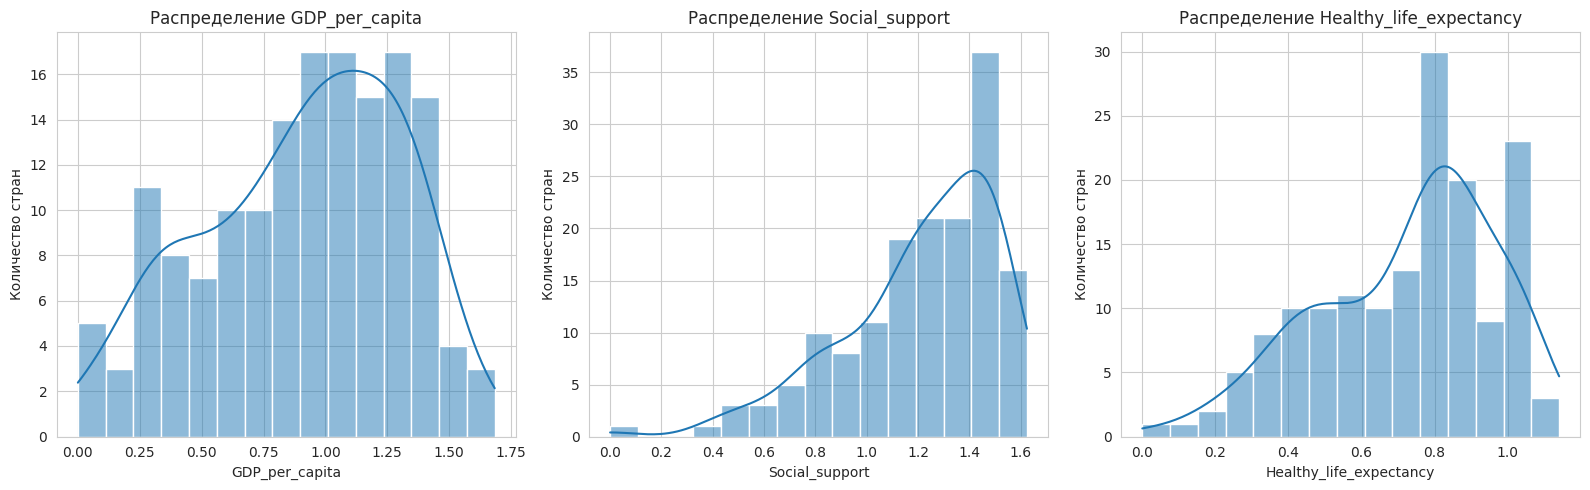

In [93]:
features = ['GDP_per_capita', 'Social_support', 'Healthy_life_expectancy']

plt.figure(figsize=(16, 5))

for i, feature in enumerate(features, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[feature], bins=15, kde=True)
    plt.title(f'Распределение {feature}')
    plt.xlabel(feature)
    plt.ylabel('Количество стран')

plt.tight_layout()
plt.show()

На этих графиках показано распределение трёх ключевых признаков:  

- `GDP_per_capita` - ВВП на душу населения  
- `Social_support` - социальная поддержка  
- `Healthy_life_expectancy` - ожидаемая продолжительность здоровой жизни  

Что показывают графики:  
- Гистограмма отображает, как часто встречаются различные значения среди всех стран.  
- Видно, что распределения относительно равномерные, небольшая скошенность у `Social_support` и `Healthy_life_expectancy`.  
- Выбросы не сильно влияют на визуализацию, поэтому данные не обрезаются и не логарифмируются.  

## 9. Распределение целевой переменной `Score`

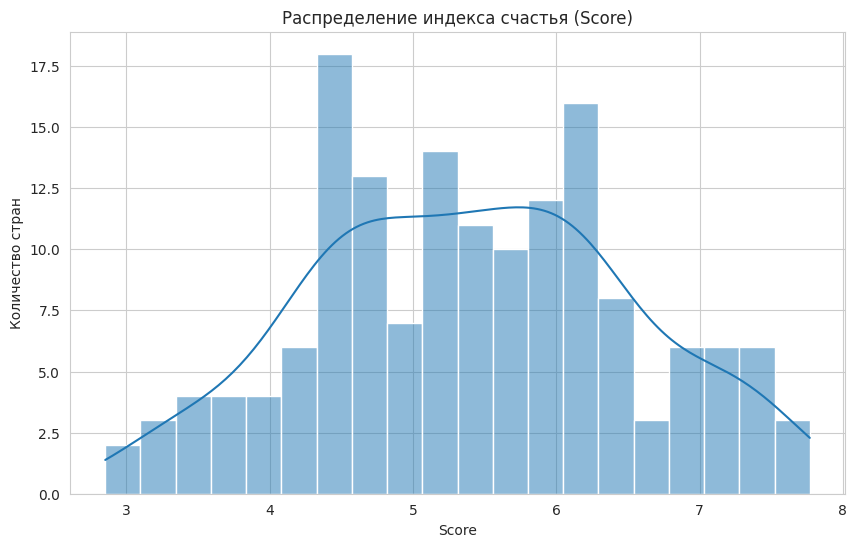

In [94]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Score'], bins=20, kde=True)
plt.title('Распределение индекса счастья (Score)')
plt.xlabel('Score')
plt.ylabel('Количество стран')
plt.show()

**Вывод:**  
Распределение `Score` выглядит достаточно плавным, без резкой асимметрии и без явного наличия экстремальных значений. Это удобно для задачи регрессии, так как целевая переменная не выглядит проблемной с точки зрения распределения.

## 10. Анализ распределения признаков и выбросов

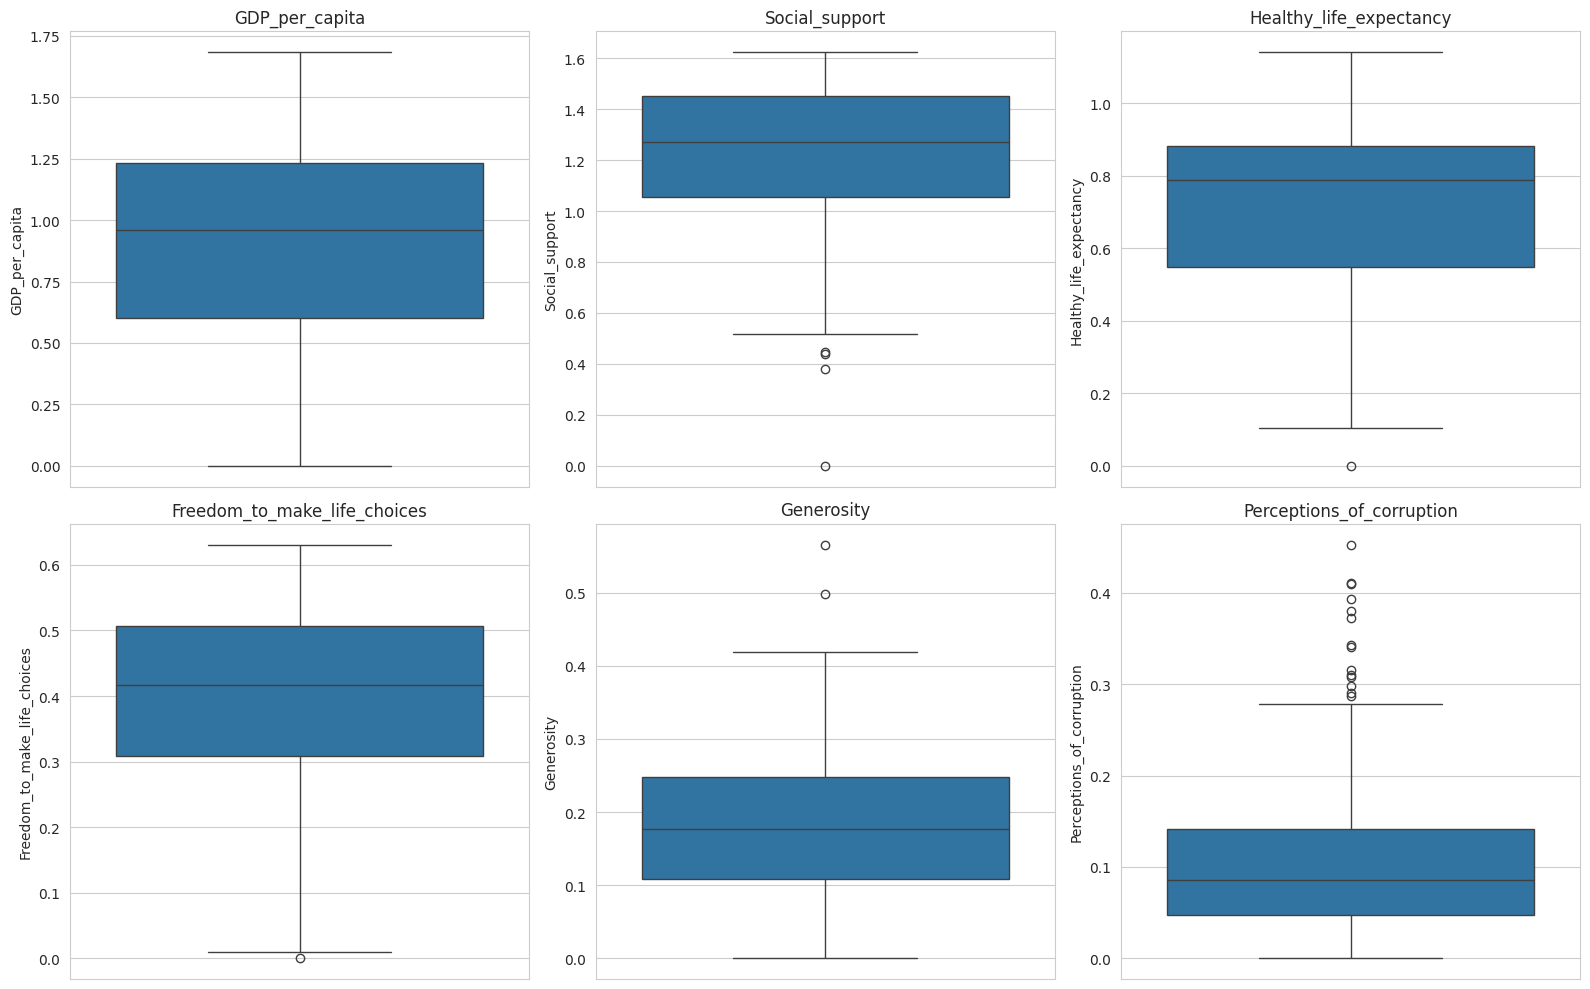

In [95]:
features = [
    'GDP_per_capita',
    'Social_support',
    'Healthy_life_expectancy',
    'Freedom_to_make_life_choices',
    'Generosity',
    'Perceptions_of_corruption'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feature in zip(axes.flat, features):
    sns.boxplot(y=df[feature], ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()

**Вывод:**  
По boxplot видно, что в некоторых признаках присутствуют наблюдения, которые можно интерпретировать как выбросы или крайние значения. Однако в данном случае это могут быть реальные особенности отдельных стран, а не ошибки в данных. Поэтому на этапе EDA удалять такие наблюдения не будем.

## 11. Корреляционный анализ

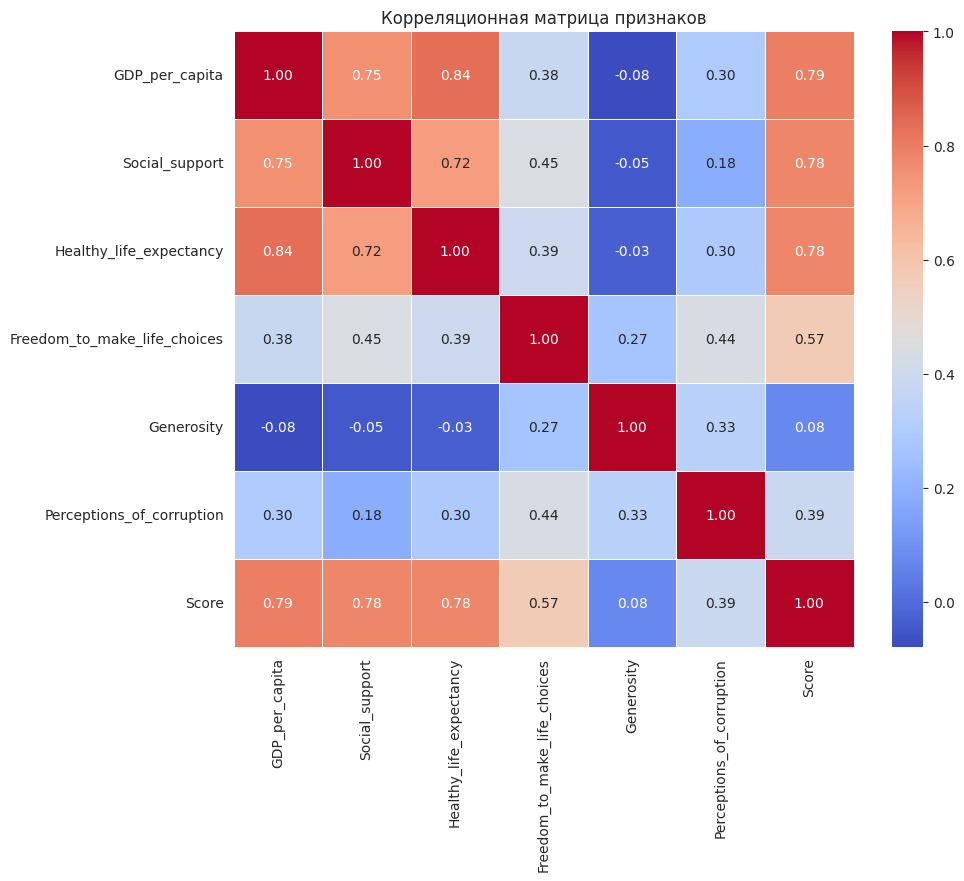

In [96]:
corr_features = features + ['Score']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()

### Комментарий к корреляционной матрице

Корреляционная матрица показывает, насколько сильно связаны признаки между собой и с целевой переменной `Score`.  

Основные наблюдения:

- Наиболее сильная положительная связь с Score наблюдается у:
  - `GDP_per_capita` - страны с более высоким ВВП обычно имеют более высокий индекс счастья.
  - `Social_support` - страны с развитой социальной поддержкой показывают более высокий уровень счастья.
  - `Healthy_life_expectancy` - более здоровая жизнь связана с более высоким индексом счастья.

- Между некоторыми признаками также видна взаимосвязь:
  - `GDP_per_capita` и `Healthy_life_expectancy` положительно коррелируют: более богатые страны обычно имеют более высокую продолжительность здоровой жизни.
  - `GDP_per_capita` и `Social_support` тоже связаны: страны с высоким экономическим благополучием часто имеют развитую систему социальной поддержки.
  - `Social_support` и `Healthy_life_expectancy` положительно коррелируют: развитая социальная поддержка может способствовать лучшему здоровью населения.

Вывод:  
Эти взаимосвязи показывают, что признаки не независимы, и модели могут учитывать как прямое влияние каждого признака на `Score`, так и косвенные связи между ними.

## 12. Зависимость `Score` от ключевых признаков

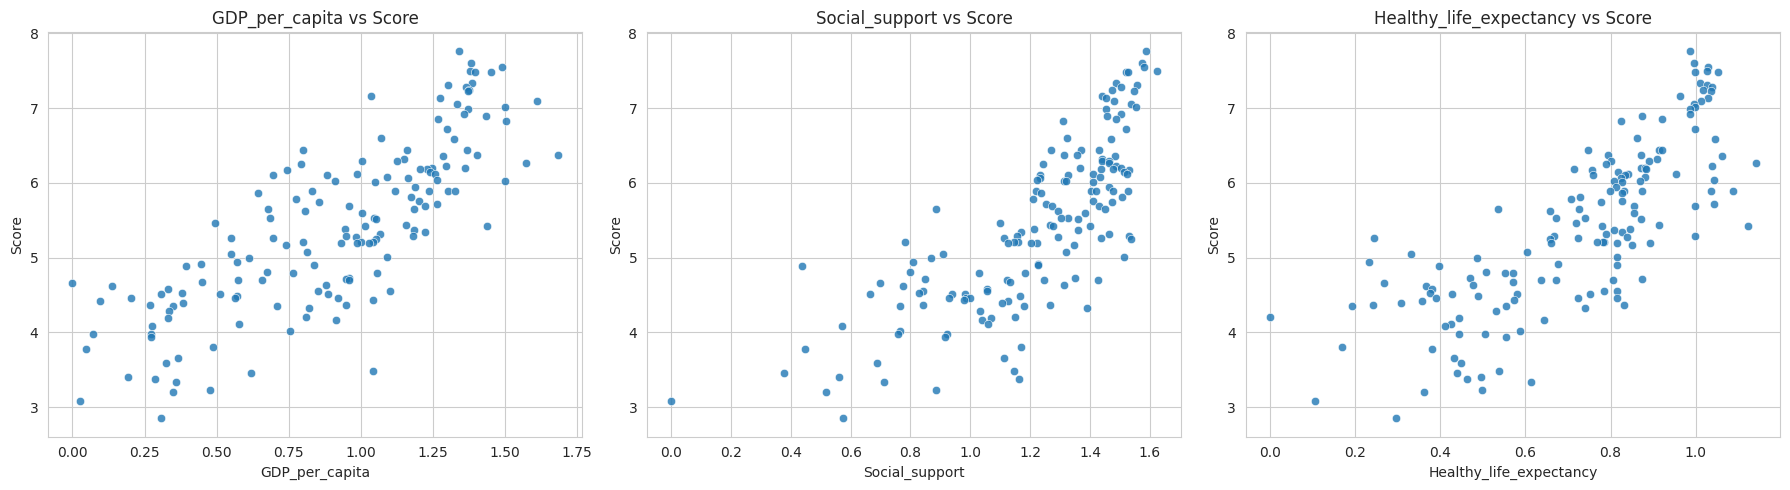

In [97]:
key_features = ['GDP_per_capita', 'Social_support', 'Healthy_life_expectancy']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, key_features):
    sns.scatterplot(data=df, x=feature, y='Score', ax=ax, alpha=0.8)
    ax.set_title(f'{feature} vs Score')

plt.tight_layout()
plt.show()

**Вывод:**  
На scatterplot видно, что между `Score` и ключевыми признаками наблюдается положительная зависимость: при росте значений признаков индекс счастья в среднем увеличивается.

## 13. Средние значения признаков и связь с `Score`

Проанализируем, как распределяются ключевые признаки среди стран с самым высоким индексом счастья (`Score`):

1. Сначала выбираем ключевые признаки: `GDP_per_capita`, `Social_support`, `Healthy_life_expectancy`.  
2. Сортируем весь датасет по целевой переменной Score в порядке убывания, чтобы сверху были страны с наибольшим уровнем счастья.  
3. Берём топ-10 стран с самым высоким `Score`.  
4. Выводим таблицу с их значениями ключевых признаков и индексом счастья.  

Цель: наглядно показать, какие признаки обычно присутствуют у самых счастливых стран и подтвердить результаты корреляционного анализа.

In [98]:
df[features + ['Score']].sort_values('Score', ascending=False).head(10)

,GDP_per_capita,Social_support,Healthy_life_expectancy,Freedom_to_make_life_choices,Generosity,Perceptions_of_corruption,Score
0,1.340,1.587,0.986,0.596,0.153,0.393,7.769
1,1.383,1.573,0.996,0.592,0.252,0.410,7.600
2,1.488,1.582,1.028,0.603,0.271,0.341,7.554
3,1.380,1.624,1.026,0.591,0.354,0.118,7.494
4,1.396,1.522,0.999,0.557,0.322,0.298,7.488
5,1.452,1.526,1.052,0.572,0.263,0.343,7.480
6,1.387,1.487,1.009,0.574,0.267,0.373,7.343
7,1.303,1.557,1.026,0.585,0.330,0.380,7.307
8,1.365,1.505,1.039,0.584,0.285,0.308,7.278
9,1.376,1.475,1.016,0.532,0.244,0.226,7.246


**Вывод:**  
Страны с наибольшими значениями `Score` действительно чаще имеют высокие значения по `GDP_per_capita`, `Social_support` и `Healthy_life_expectancy`. Это подтверждает результаты корреляционного и графического анализа.


### Группировка стран по уровням Score

Разделим страны на 3 группы по квантилям `Score`: низкий (low), средний (medium), высокий (high).  
Это позволяет сравнить средние значения признаков между группами.

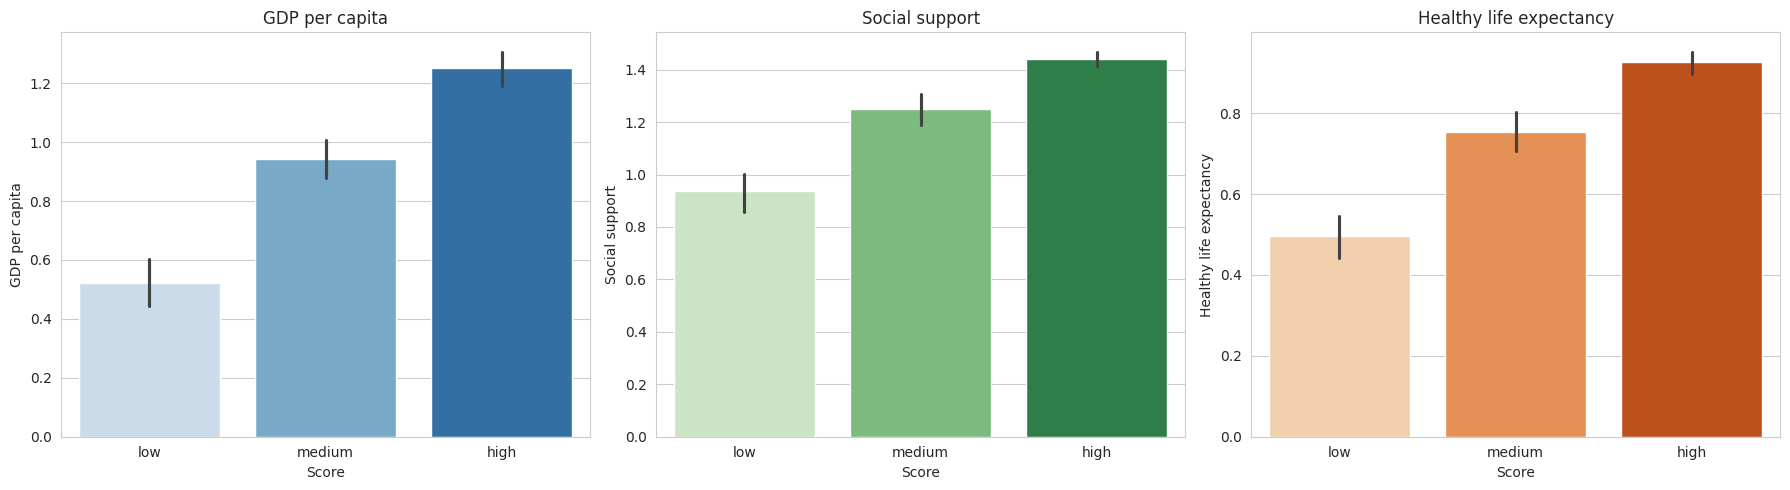

In [99]:
df['Score_group'] = pd.qcut(df['Score'], q=3, labels=['low','medium','high'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='Score_group', y='GDP_per_capita', ax=axes[0], palette='Blues')
axes[0].set_title('GDP per capita')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('GDP per capita')

sns.barplot(data=df, x='Score_group', y='Social_support', ax=axes[1], palette='Greens')
axes[1].set_title('Social support')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Social support')

sns.barplot(data=df, x='Score_group', y='Healthy_life_expectancy', ax=axes[2], palette='Oranges')
axes[2].set_title('Healthy life expectancy')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Healthy life expectancy')

plt.tight_layout()
plt.show()

**Вывод:**  
Все три фактора демонстрируют чёткую положительную связь с уровнем счастья  `Score`: средние значения `GDP per capita`, `Social support` и `Healthy life` expectancy последовательно возрастают от группы low к группе high.


### Spearman корреляция

Spearman фиксирует ранговые зависимости между признаками и `Score`, полезно для выявления сильных зависимостей даже при нелинейных отношениях.

In [100]:
df[['Score','GDP_per_capita','Social_support','Healthy_life_expectancy']].corr(method='spearman')

,Score,GDP_per_capita,Social_support,Healthy_life_expectancy
Score,1.000000,0.814483,0.816181,0.807275
GDP_per_capita,0.814483,1.000000,0.768539,0.851513
Social_support,0.816181,0.768539,1.000000,0.725997
Healthy_life_expectancy,0.807275,0.851513,0.725997,1.000000


**Вывод:**  
Ранговые корреляции подтверждают сильную положительную связь всех трёх факторов с индексом счастья. Самую сильную связь со `Score` показывает `Social_support` (0.816), за ним следует `GDP_per_capita` (0.814). Признаки также сильно связаны между собой, особенно `GDP_per_capita` и `Healthy_life_expectancy` (0.851). Близость значений к пирсоновским корреляциям говорит о том, что зависимости действительно близки к линейным и не искажены выбросами.

## 14. Итоговые выводы по EDA



По результатам разведочного анализа датасета World Happiness Report 2019 можно сделать следующие выводы:

1. Структура и качество данных
   - Датасет небольшой, содержит 156 наблюдений и 9 столбцов, что удобно для анализа.  
   - Пропусков в данных нет, все признаки корректно заполнены.  
   - Структура данных понятна, признаки количественные, кроме текстового столбца с названием страны, который не используется в моделировании.

2. Целевая переменная
   - Целевая переменная `Score` (индекс счастья) подходит для задачи регрессии.  
   - Распределение `Score` относительно плавное, без сильных выбросов или резкой асимметрии, что делает её удобной для построения моделей линейной и соседской регрессии.

3. Ключевые признаки
   - Наиболее значимыми признаками для объяснения вариации `Score` оказались:
     - `GDP_per_capita` - отражает экономическое благополучие страны.
     - `Social_support` - показывает уровень социальной поддержки граждан.
     - `Healthy_life_expectancy` - характеризует среднюю ожидаемую продолжительность здоровой жизни.
   - Эти признаки положительно коррелируют с `Score` и среди стран с наивысшими значениями счастья имеют высокие значения.

4. Взаимосвязь между признаками
   - Некоторые признаки взаимосвязаны между собой:
     - `GDP_per_capita` и `Healthy_life_expectancy` положительно коррелируют: богатые страны имеют более долгую здоровую жизнь.  
     - `GDP_per_capita` и `Social_support` положительно связаны: экономически развитые страны чаще имеют развитую систему социальной поддержки.  
     - `Social_support` и `Healthy_life_expectancy` тоже коррелируют: развитая социальная поддержка может способствовать лучшему здоровью населения.
   - Эти взаимосвязи нужно учитывать при построении моделей, так как признаки не полностью независимы.

5. Распределение и выбросы
   - Распределение ключевых признаков сравнительно равномерное, небольшая скошенность у `Social_support` и `Healthy_life_expectancy`.  
   - Выбросов немного, их влияние на общую картину умеренное, поэтому их не обрезали и не трансформировали при визуализации.


## 15. Выбор моделей
Для дальнейшего решения задачи регрессии используются две модели:
### 1. Linear Regression
Линейная регрессия будет использоваться как базовая модель. Она проста, интерпретируема и позволяет понять, насколько хорошо целевая переменная описывается линейной зависимостью от признаков.
### 2. KNN Regressor
Метод ближайших соседей позволяет учитывать нелинейные зависимости и взаимодействия между признаками. Эта модель подходит для табличных данных и может быть легко интерпретируема при небольшом числе признаков.

## 16. Выбор метрик качества
Для оценки качества моделей используются следующие метрики, которые применимы к регрессии:
### 1. Mean Squared Error (MSE)
Показывает среднеквадратичную ошибку прогноза.  
Метрика показывает, насколько в среднем модель ошибается в предсказании индекса счастья.
### 2. R² (коэффициент детерминации)
Показывает, какую долю вариации целевой переменной объясняет модель.  
Удобна для общей оценки качества регрессионной модели.

## 17. Формулировка задачи

В данной работе рассматривается задача **регрессии**.
- **Целевая переменная:** `Score`
- **Что нужно предсказать:** уровень счастья страны
- **Признаки для моделирования:**
    - `GDP_per_capita`
    - `Social_support`
    - `Healthy_life_expectancy`
    - `Freedom_to_make_life_choices`
    - `Generosity`
    - `Perceptions_of_corruption`

Столбцы `Overall_rank` и `Country_or_region` не будем использовать как признаки:
- `Overall_rank` фактически отражает положение страны по уровню счастья и тесно связан с целевой переменной;
- `Country_or_region` является текстовым полем и в рамках базового анализа не используется.